Mini-projekt: Twój własny zbiór danych

Cele: samodzielna eksploracja danych i ich prezentacja; rozwój kreatywności i samodzielności.

Polecenia:
Znajdź lub wybierz mały otwarty zbiór danych CSV (np. z Kaggle, data.gov, Eurostat).
Tematy: sport, transport, edukacja, zdrowie, film, muzyka.

Załaduj dane w Jupyter Notebook i:

pokaż podstawowe informacje (info, describe),

usuń błędne lub puste dane,

wykonaj 2–3 analizy statystyczne (np. średnia, min, max, korelacje).

Stwórz jeden wykres (np. słupkowy, boxplot, scatter lub heatmapę).

Zinterpretuj wykres i napisz krótki raport (5–6 zdań) o swoich obserwacjach.

Umieść tytuł, autora i źródło danych w komórce Markdown na początku notebooka.

Top 100 najpopularniejszych filmów 2003-2022 (iMBD) - George Scutelnicu - kaggle.com

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Top100Movies.csv')

In [160]:
print("---First 5 rows of the dataset---")
print(df.head())

---First 5 rows of the dataset---
                            Title  Rating  Year     Month Certificate Runtime  \
0        Avatar: The Way of Water     7.8  2022  December       PG-13     192   
1  Guillermo del Toro's Pinocchio     7.6  2022  December          PG     117   
2                    Bullet Train     7.3  2022    August           R     127   
3       The Banshees of Inisherin     7.8  2022  November           R     114   
4                           M3gan     6.4  2022  December       PG-13     102   

                            Directors  \
0                       James Cameron   
1  Guillermo del Toro, Mark Gustafson   
2                        David Leitch   
3                     Martin McDonagh   
4                    Gerard Johnstone   

                                               Stars  \
0  Sam Worthington, Zoe Saldana, Sigourney Weaver...   
1  Ewan McGregor, David Bradley, Gregory Mann, Bu...   
2  Brad Pitt, Joey King, Aaron Taylor Johnson, Br...   
3  Colin

In [161]:
print("---Info---")
print(df.info())
print("---Describe---")
print(df.describe())

---Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              2000 non-null   object 
 1   Rating             1999 non-null   float64
 2   Year               2000 non-null   int64  
 3   Month              2000 non-null   object 
 4   Certificate        1966 non-null   object 
 5   Runtime            2000 non-null   object 
 6   Directors          2000 non-null   object 
 7   Stars              2000 non-null   object 
 8   Genre              2000 non-null   object 
 9   Filming_location   2000 non-null   object 
 10  Budget             2000 non-null   object 
 11  Income             2000 non-null   object 
 12  Country_of_origin  2000 non-null   object 
dtypes: float64(1), int64(1), object(11)
memory usage: 203.3+ KB
None
---Describe---
            Rating         Year
count  1999.000000  2000.000000
mean      6.6

In [162]:
print("---Missing values---")
print(df.isnull().sum())
#print(df.count())
df = df.dropna().drop_duplicates()
#print(df.count())

---Missing values---
Title                 0
Rating                1
Year                  0
Month                 0
Certificate          34
Runtime               0
Directors             0
Stars                 0
Genre                 0
Filming_location      0
Budget                0
Income                0
Country_of_origin     0
dtype: int64


In [163]:
print("Change columns: Budget, Income to numeric")
df['Budget'] = pd.to_numeric(
    df['Budget'].str.replace(r"[\$, ]", "", regex=True),
    errors="coerce"
)
df['Income'] = pd.to_numeric(
    df['Income'].str.replace(r"[\$, ]", "", regex=True),
    errors="coerce"
)
print(df['Budget'][0:1])
print(df['Income'][0:1])

Change columns: Budget, Income to numeric
0    350000000.0
Name: Budget, dtype: float64
0    2.267947e+09
Name: Income, dtype: float64


In [164]:
print(df['Year'].min())
print(df['Year'].max())

2003
2022


In [165]:
print("Average rating per year")
rating_year = df.groupby('Year')['Rating'].mean()
print(rating_year)

Average rating per year
Year
2003    6.579000
2004    6.746000
2005    6.578788
2006    6.713000
2007    6.756000
2008    6.614141
2009    6.703061
2010    6.661616
2011    6.731313
2012    6.665657
2013    6.716162
2014    6.770408
2015    6.672727
2016    6.789899
2017    6.758163
2018    6.671717
2019    6.704040
2020    6.353608
2021    6.619388
2022    6.653488
Name: Rating, dtype: float64


In [166]:
print("Max income per year")
max_income = df.groupby('Year')['Income'].max()#.astype(int)
print(max_income)

#plt.plot(max_income)

Max income per year
Year
2003    1.146458e+09
2004    9.287608e+08
2005    8.968151e+08
2006    1.066180e+09
2007    9.609965e+08
2008    1.006234e+09
2009    2.922918e+09
2010    1.066971e+09
2011    1.342360e+09
2012    1.518816e+09
2013    1.304551e+09
2014    1.104054e+09
2015    2.069522e+09
2016    1.153337e+09
2017    1.332699e+09
2018    2.048360e+09
2019    2.797501e+09
2020    4.532110e+08
2021    1.917430e+09
2022    2.267947e+09
Name: Income, dtype: float64


In [167]:
print("Min budget per year")
min_budget = df.groupby('Year')['Budget'].min()
print(min_budget)

Min budget per year
Year
2003     500000.0
2004       7000.0
2005     475000.0
2006    2000000.0
2007      15000.0
2008     230000.0
2009    2000000.0
2010     500000.0
2011     500000.0
2012     242000.0
2013      50000.0
2014    1000000.0
2015     100000.0
2016      35000.0
2017    2000000.0
2018      11000.0
2019    4000000.0
2020    2000000.0
2021     820000.0
2022     250000.0
Name: Budget, dtype: float64


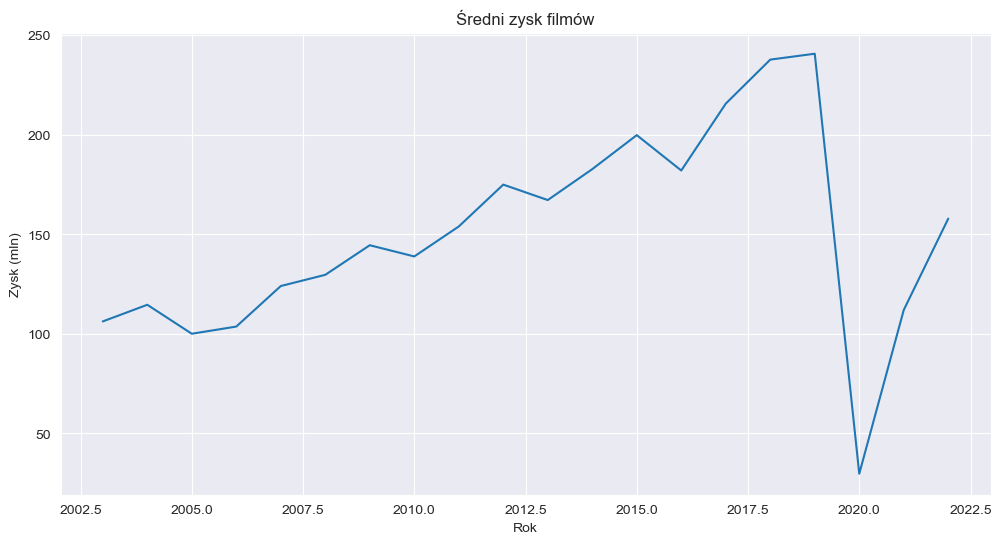

In [168]:
df['Profit'] = df['Income'] - df['Budget']
mean_profit = df.groupby('Year')['Profit'].mean() / 1000000
#print(mean_profit)

plt.figure(figsize=(12, 6))
plt.plot(mean_profit)
plt.title('Średni zysk filmów')
plt.xlabel('Rok')
plt.ylabel('Zysk (mln)')
plt.grid(True)
plt.show()

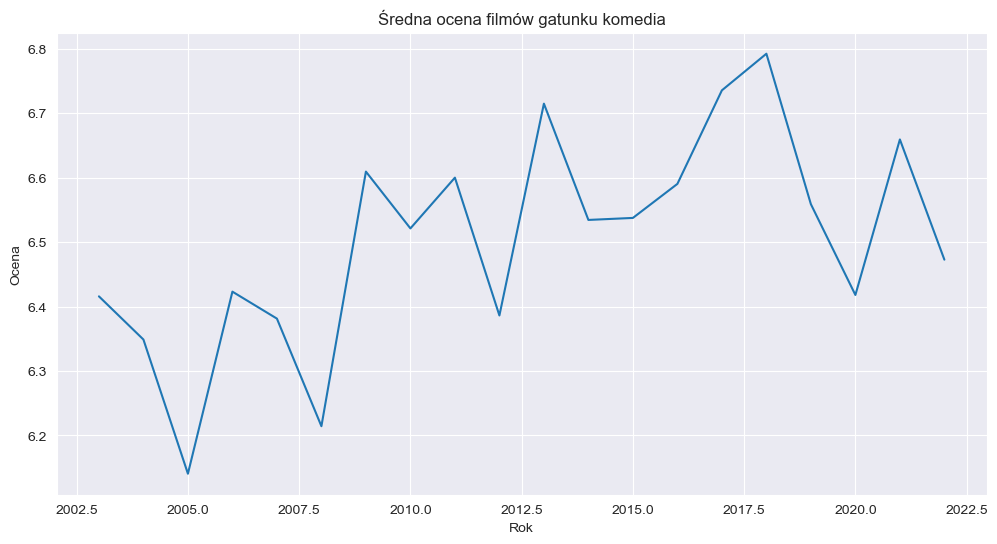

In [169]:
genre = df['Genre'].str.contains('Comedy')
df_Genre = df[genre].copy()
mean_rating = df_Genre.groupby('Year')['Rating'].mean()
#print(mean_rating)

plt.figure(figsize=(12, 6))
plt.plot(mean_rating)
plt.title('Średna ocena filmów gatunku komedia')
plt.xlabel('Rok')
plt.ylabel('Ocena')
plt.grid(True)
plt.show()

Średnie oceny najlepszych filmów utrzymują się w granicy 6.5/10
Rekordowy przychód wyniósł prawie 3 mld w 2009 roku
W 2004 nakręcono topowy film przy budżecie 7 000$
W latach 2018-2020 gwałtownie spadł zysk wszyskich filmów
